# Oscillatore armonico
Giovanni Nicola D'Aloisio, n. di matricola 494722; prova svolta il 21 aprile 2021.

---

## Introduzione
<p align="justify">Un oscillatore armonico è un sistema meccanico che reagisce ad una perturbazione dell'equilibrio con una accelerazione di richiamo proporzionale allo spostamento subito, secondo la legge di Hooke. In particolare, se una massa sferica collegata a una molla a riposo viene perturbata mediante un'elongazione una volta rilasciata inizierà a muoversi di moto armonico smorzato attorno alla posizione di equilibrio, nella quale la risultante delle forze di gravità e di richiamo è nulla. È dunque possibile stabilire, dall'analisi di questo moto, la costante elastica della molla e la sua massa effettiva e valutare l'accelerazione gravitazionale alla quale è sottoposta.

## Scopi della prova
Gli obiettivi della prova sono:
* Verificare la legge di Hooke e determinare la costante elastica di una molla con il metodo statico;
* Verificare la legge di Hooke e determinare la costante elastica e la massa effettiva della molla con il metodo dinamico;
* Determinare l'accelerazione di gravità dalla combinazione dei due metodi.

## Apparato sperimentale
Per raggiungere gli obiettivi della prova si dispone di:
* Una molla elicoidale di massa nota;
* Una serie di masse, di cui una di forma sferica;
* Un metro, per misurare la lunghezza della molla;
* Un sostegno orizzontale sopraelevato, per sostenere il sistema molla-masse;
* Un sensore di moto, per rilevare la posizione della molla nel tempo.

## Procedura
<p align="justify">Nella prima parte della prova, sapendo che il sistema costituito dalla molla e dalle masse a essa agganciate è in equilibrio se e solo se:

> $F = M g = k x_M$

<p align="justify">Per più valori di massa si calcola la forza-peso $F \pm \delta F$ alla quale è soggetta la molla e la si correla all'elongazione $x_M \pm \delta x_m$ misurata. Allora dal best-fit della legge precedente si ricava il valore della costante elastica $k \pm \delta k$.

<p align="justify">Applicando un'elongazione verticale sulla molla con valori diversi di massa, dato che quest'ultima è immersa in un mezzo come l'aria, essa si muoverà di moto armonico smorzato:

> $x(t)= A e^{- \gamma t} \cos (\omega_s t + \phi) + x_M$

<p align="justify">Eseguendo un best-fit di tale legge utilizzando i parametri di posizione nel tempo ottenuti con il sensore di moto, si ricavano l'ampiezza dell'oscillazione $A \pm \delta A$, la pulsazione $\omega_s \pm \delta \omega_s$, la fase $\phi \pm \delta \phi$, il fattore di smorzamento $\gamma_s \pm \delta \gamma_s$ e il punto di equilibrio $x_M \pm \delta x_M$.

<p align="justify">Dalla pulsazione trovata, sapendo che il periodo $T_0 = {2 \pi \over \omega_s}$ è legato alla massa effettiva della molla dalla relazione:

> $M = k \frac{T_0^2}{4 \pi^2} - m_e$

<p align="justify">si ricavano i valori della costante elastica $k \pm \delta k$ e della massa effettiva $m_e \pm \delta m_e$ per ogni prova.

<p align="justify">Infine, sapendo che il valore della posizione di equilibrio calcolata con il metodo dinamico è meno affidabile di quello determinato nella prova statica, si possono combinare i due metodi per trovare il valore dell'accelerazione di gravità a Pavia. Difatti:

> $x_M = g \frac{T_0^2}{2 \pi^2} - {m_e g \over k}$

Eseguendo il best fit di tale legge con i valori di $x_M \pm \delta x_M$ statici e $T_0 \pm \delta T_0$ dinamici si ottiene il valore di $g \pm \delta g$.

## Analisi dei dati sperimentali
In questa sezione sono riportati gli script in Python utilizzati per l'analisi dei dati sperimentali, con i relativi risultati.

In [ ]:
# Da eseguire all'inizio

import numpy as np
from matplotlib import pyplot as plt 
from scipy.optimize import curve_fit 
from scipy import odr, constants

### Costante elastica della molla con metodo statico

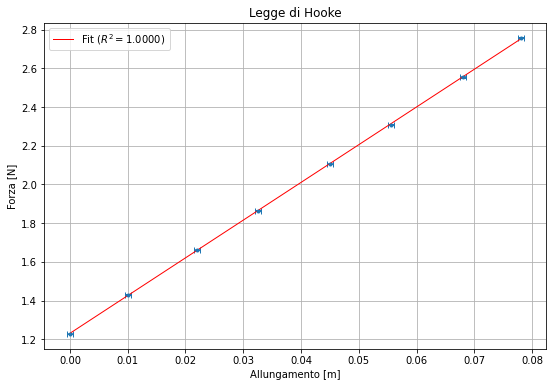

	 y₀ =     1.2304 +/- 0.0024
	 k =    19.5048 +/- 0.0529
	 R² = 0.9999557055186872


In [ ]:
# Dati globali

L_err = 0.0005                                            # Errore assoluto in m per ogni misura di lunghezza

# Importazione dati grezzi per il fit (S.I.)

dati = np.loadtxt('https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210421%20-%20Molla/Misure_statiche.txt', dtype=np.str, delimiter="\t", skiprows=1)

Peso = dati[:,0]
Peso = Peso.astype(np.float)
Peso = Peso*9.805

x = dati[:,1]
x = x.astype(np.float)

Peso_err = dati[:,2]
Peso_err = Peso_err.astype(np.float)
Peso_err = Peso_err*9.805

x_err = dati[:,3]
x_err = x_err.astype(np.float)

# Definizione funzione di fit 
def retta(p,elongazione): 
  return p[0]+p[1]*elongazione

# Fitting routine

def fitplot_retta(y0, k, print_output=True, plot_guess=False):

  retta_model = odr.Model(retta)
  fit_data = odr.RealData(x, Peso, sx=x_err, sy=Peso_err)
  beta0 = np.array([y0,k])
  
  fit = odr.ODR(fit_data, retta_model, beta0=beta0)
  global out
  out = fit.run()
  
  # Calcolo il coefficiente R2 per valutare la bontà del fit

  residuals = Peso - retta(out.beta, x)
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((Peso-np.mean(Peso))**2)
  r_squared = 1 - (ss_res / ss_tot)

  # Plot dei risultati

  sample_x = np.linspace(0,np.amax(x),1000)
  plt.show()
  plt.figure(figsize=(9, 6))

  if plot_guess:
    plt.plot(sample_x, retta(beta0,sample_x),'--', color=[0.3,0.7,0], label="Guess", linewidth=1)

  plt.errorbar(x, Peso, xerr=x_err, yerr=Peso_err, linestyle='None', capsize=3, marker='.')
  plt.title("Legge di Hooke")
  plt.xlabel("Allungamento [m]")
  plt.ylabel("Forza [N]")
  plt.plot(sample_x, retta(out.beta, sample_x), color=[1,0,0], label="Fit ($R^2=${:.4f})".format(r_squared), linewidth=1)
  plt.grid(which='both')
  plt.legend()
  plt.show()
    
  if print_output:
      print("\t y₀ = {:10.4f} +/- {:2.4f}".format(out.beta[0],out.sd_beta[0]))
      print("\t k = {:10.4f} +/- {:2.4f}".format(out.beta[1],out.sd_beta[1]))
      print("\t R² = "+str(r_squared))

fitplot_retta(5, 5)             # Parametri consigliati: (5, 5)

### Costante elastica e massa effettiva della molla con metodo dinamico

In [ ]:
# Download dati raw e definizione ciclo per fit - Le masse implicate in ogni prova sono uguali a quelle della rispettiva prova statica

hub_data = ['https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210421%20-%20Molla/Misure_dinamiche/Ril1.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210421%20-%20Molla/Misure_dinamiche/Ril2.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210421%20-%20Molla/Misure_dinamiche/Ril3.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210421%20-%20Molla/Misure_dinamiche/Ril6.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210421%20-%20Molla/Misure_dinamiche/Ril7.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210421%20-%20Molla/Misure_dinamiche/Ril12.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210421%20-%20Molla/Misure_dinamiche/Ril13.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210421%20-%20Molla/Misure_dinamiche/Ril16.txt']

fit_params = []

for url in hub_data:

  # Importazione dati per il fit

  dati = np.loadtxt(url, dtype=np.str, delimiter="\t", skiprows=1)
  dati = np.char.replace(dati, ',', '.')
  dati = dati[:,0:2]
  dati = dati.astype(np.float)

  t = dati[:,0]
  y = dati[:,1]

  # Definizione della funzione di fit

  def damped_sine(t,A,omega,phi,gamma,y0): 
    return A*np.exp(-gamma*t)*np.sin(omega*t+phi)+y0

  # Fitting routine
  
  def fitplot_sin(A, omega, y0, phi, gamma, print_output=True, plot_guess=False):
  
    guess = np.array([A,omega,phi,gamma,y0])
    bounds = ([0,0,-np.pi,0,0], [10., 25, np.pi,1,10]) 
  
    global popt, pcov
  
    popt, pcov = curve_fit(damped_sine, t, y, p0=guess, bounds=bounds)

    # Calcolo il coefficiente R2 per valutare la bontà del fit

    residuals = y - damped_sine(t,popt[0],popt[1],popt[2],popt[3],popt[4])
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y-np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot) 

    # Plot dei risultati - Scommentare per vedere anche i plot

#    plt.figure(figsize=(7, 3))

#    if plot_guess:
#      plt.plot(t, damped_sine(t, guess[0], guess[1], guess[2],guess[3],guess[4]),'--', color=[0.3,0.7,0], label="Guess", linewidth=2)
    
#    plt.scatter(t,y,s=20,label="Exp.")
#    plt.plot(t,damped_sine(t,popt[0],popt[1],popt[2],popt[3],popt[4]),color=[1,0,0],label="Fit ($R^2=${:.4f})".format(r_squared),linewidth=2)
#    plt.grid(which='both')
#    plt.legend()
#    plt.show()
    
    # Esportazione parametri dei fit
    # Lista del tipo [[A, dA], [ω, dω], [ϕ, dϕ], [γ, dγ], [R, 0]]

    parametri = []

    for v, e in zip(popt, np.sqrt(np.diag(pcov))):
      parametri.append([v,e])
    
    parametri.append([r_squared, 0])

    fit_params.append(parametri)

  fitplot_sin(10, 10, 10, 0, 0)    # Parametri consigliati per ciclo for unico: (10, 10, 10, 0, 0)

fit_params = np.array(fit_params)

#print(fit_params)                 # Scommentare per visualizzare i risultati del fit sinusoidale

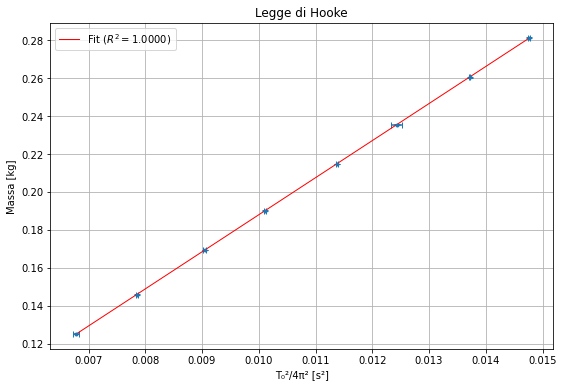

	 k =    19.5476 +/- 0.0201
	 mₑ =     0.0075 +/- 0.0002
	 R² = 0.999995071889003


In [ ]:
# Importazione dati grezzi per il fit (S.I.)

dati = np.loadtxt('https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210421%20-%20Molla/Misure_statiche.txt', dtype=np.str, delimiter="\t", skiprows=1)

x = []

for i in fit_params:
  x.append((1/(i[1])[0])**2)

x = np.array(x)

x_err = []

for i in fit_params:
  x_err.append((1/(i[1])[0])*(i[1])[1])

x_err = np.array(x_err)

Peso = dati[:,0]
Peso = Peso.astype(np.float)

Peso_err = dati[:,2]
Peso_err = Peso_err.astype(np.float)

# Definizione funzione di fit 
def retta(p,roba): 
  return (p[0]*roba)-p[1]

# Fitting routine

def fitplot_retta(y0, k, print_output=True, plot_guess=False):

  retta_model = odr.Model(retta)
  fit_data = odr.RealData(x, Peso, sx=x_err, sy=Peso_err)
  beta0 = np.array([y0,k])
  
  fit = odr.ODR(fit_data, retta_model, beta0=beta0)
  global out
  out = fit.run()
  
  # Calcolo il coefficiente R2 per valutare la bontà del fit

  residuals = Peso - retta(out.beta, x)
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((Peso-np.mean(Peso))**2)
  r_squared = 1 - (ss_res / ss_tot)

  # Plot dei risultati

  sample_x = np.linspace(np.amin(x),np.amax(x),1000)
  plt.show()
  plt.figure(figsize=(9, 6))

  if plot_guess:
    plt.plot(sample_x, retta(beta0,sample_x),'--', color=[0.3,0.7,0], label="Guess", linewidth=1)

  plt.errorbar(x, Peso, xerr=x_err, yerr=Peso_err, linestyle='None', capsize=3, marker='.')
  plt.title("Legge di Hooke")
  plt.xlabel("T₀²/4π² [s²]")
  plt.ylabel("Massa [kg]")
  plt.plot(sample_x, retta(out.beta, sample_x), color=[1,0,0], label="Fit ($R^2=${:.4f})".format(r_squared), linewidth=1)
  plt.grid(which='both')
  plt.legend()
  plt.show()
    
  if print_output:
      print("\t k = {:10.4f} +/- {:2.4f}".format(out.beta[0],out.sd_beta[0]))
      print("\t mₑ = {:10.4f} +/- {:2.4f}".format(out.beta[1],out.sd_beta[1]))
      print("\t R² = "+str(r_squared))

fitplot_retta(5, 5)             # Parametri consigliati: (5, 5)

### Accelerazione di gravità $g$ con metodo combinato

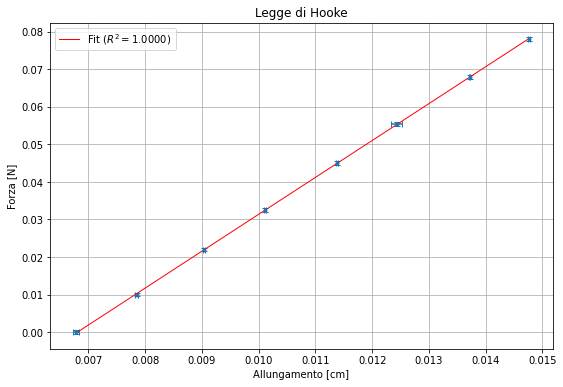

	 g =     9.8291 +/- 0.0231
	 y₀ =     0.0669 +/- 0.0003
	 R² = 0.9999604786328855


In [ ]:
# Importazione dati grezzi per il fit (S.I.)

dati = np.loadtxt('https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210421%20-%20Molla/Misure_statiche.txt', dtype=np.str, delimiter="\t", skiprows=1)

x = []

for i in fit_params:
  x.append((1/(i[1])[0])**2)

x = np.array(x)

x_err = []

for i in fit_params:
  x_err.append((1/(i[1])[0])*(i[1])[1])

x_err = np.array(x_err)

Peso = dati[:,1]
Peso = Peso.astype(np.float)

Peso_err = dati[:,3]
Peso_err = Peso_err.astype(np.float)

# Definizione funzione di fit 
def retta(p,roba): 
  return (p[0]*roba) - p[1]

# Fitting routine

def fitplot_retta(y0, k, print_output=True, plot_guess=False):

  retta_model = odr.Model(retta)
  fit_data = odr.RealData(x, Peso, sx=x_err, sy=Peso_err)
  beta0 = np.array([y0,k])
  
  fit = odr.ODR(fit_data, retta_model, beta0=beta0)
  global out
  out = fit.run()
  
  # Calcolo il coefficiente R2 per valutare la bontà del fit

  residuals = Peso - retta(out.beta, x)
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((Peso-np.mean(Peso))**2)
  r_squared = 1 - (ss_res / ss_tot)

  # Plot dei risultati

  sample_x = np.linspace(np.amin(x),np.amax(x),1000)
  plt.show()
  plt.figure(figsize=(9, 6))

  if plot_guess:
    plt.plot(sample_x, retta(beta0,sample_x),'--', color=[0.3,0.7,0], label="Guess", linewidth=1)

  plt.errorbar(x, Peso, xerr=x_err, yerr=Peso_err, linestyle='None', capsize=3, marker='.')
  plt.title("Legge di Hooke")
  plt.xlabel("Allungamento [cm]")
  plt.ylabel("Forza [N]")
  plt.plot(sample_x, retta(out.beta, sample_x), color=[1,0,0], label="Fit ($R^2=${:.4f})".format(r_squared), linewidth=1)
  plt.grid(which='both')
  plt.legend()
  plt.show()
    
  if print_output:
      print("\t g = {:10.4f} +/- {:2.4f}".format(out.beta[0],out.sd_beta[0]))
      print("\t y₀ = {:10.4f} +/- {:2.4f}".format(out.beta[1],out.sd_beta[1]))
      print("\t R² = "+str(r_squared))

fitplot_retta(5, 5)             # Parametri consigliati: (5, 5)

## Discussione dei risultati e conclusioni

<p align="justify">Dall'analisi dei dati sperimentali sono stati ottenuti i seguenti valori per la costante elastica della molla:

> $k_s = (19.50 \pm 0.05) \text{ N/m} \quad \simeq \quad k_d = (19.55 \pm 0.02) \text{ N/m}$

<p align="justify">Dato che $|k_s - k_d| \leq \delta k_s + \delta k_d$, i due valori risultano compatibili, dunque egualmente corretti.

<p align="justify">Dalla prova dinamica, in particolare, si è riscontrata una massa effettiva pari a:

> $m_e = (0.0075 \pm 0.0002) \text{ kg}$

<p align="justify">Infine dalla combinazione dei valori di punto di equilibrio e periodo di ogni prova statica e dinamica risulta:

> $g_\text{ Pavia} = (9.83 \pm 0.03) \text{ m s}^{-2}$

<p align="justify">Anche questo risultato è compatibile con quello tabulato ($g_\text{ Pavia} = 9.805 \text{ m s}^{-2}$), per cui viene considerato corretto.

<p align="justify">Per i risultati ottenuti, si considerano allora raggiunti tutti gli obiettivi della prova.